# **3.1 Text Preprocessing, Tokenization, and Sequence Padding:**

## **3.3.1 Loading Dataset**

In [1]:
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
train_dataset_path = '/content/drive/MyDrive/AI and ML/ Racist Sexist or Not Dataset/train_racisit.csv'
test_dataset_path = '/content/drive/MyDrive/AI and ML/ Racist Sexist or Not Dataset/test_racisit.csv'

In [4]:
df = pd.read_csv(train_dataset_path)
df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [5]:
df[df['label'] == 1]['tweet']

,tweet
13,@user #cnn calls #michigan middle school 'buil...
14,no comment! in #australia #opkillingbay #se...
17,retweet if you agree!
23,@user @user lumpy says i am a . prove it lumpy.
34,it's unbelievable that in the 21st century we'...
...,...
31934,lady banned from kentucky mall. @user #jcpenn...
31946,@user omfg i'm offended! i'm a mailbox and i'...
31947,@user @user you don't have the balls to hashta...
31948,"makes you ask yourself, who am i? then am i a..."


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


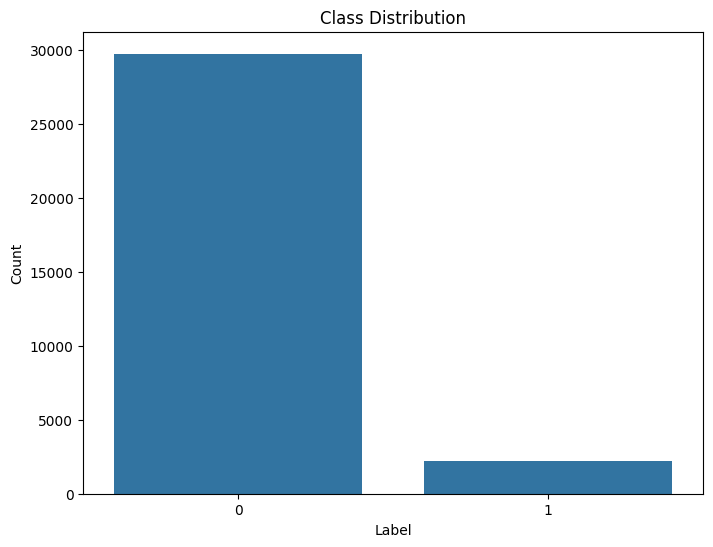

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='label')
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [8]:
df = df.drop(columns=['id'])

In [9]:
df.head()

,label,tweet
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


## **3.1.2 Data Cleaning and Normalization**

In [10]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

slang_dict = {
    "gr8": "great",
    "b4": "before",
    "u": "you",
    "ur": "your",
    "r": "are",
    "lol": "laugh",
    "omg": "oh my god",
    "idk": "i do not know",
    "btw": "by the way"
}

def preprocess_text(text):
    contractions = {
        "won't": "will not", "can't": "can not",
        "n't": " not", "'re": " are", "'s": " is",
        "'d": " would", "'ll": " will", "'t": " not",
        "'ve": " have", "'m": " am"
    }

    for pattern, repl in contractions.items():
        text = re.sub(pattern, repl, text)

    text = re.sub(r'\buser\w*\b', '', text, flags=re.IGNORECASE)

    text = text.lower()

    for slang, full in slang_dict.items():
        text = re.sub(r'\b' + re.escape(slang) + r'\b', full, text)

    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[@#]', '', text)

    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(' ', text)

    text = re.sub(r'[^\w\s]', '', text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return ' '.join(tokens)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [11]:
df['cleaned_tweet'] = df['tweet'].apply(preprocess_text)

In [12]:
df

,label,tweet,cleaned_tweet
0,0,@user when a father is dysfunctional and is s...,father dysfunctional selfish drag kid dysfunct...
1,0,@user @user thanks for #lyft credit i can't us...,thanks lyft credit use cause offer wheelchair ...
2,0,bihday your majesty,bihday majesty
3,0,#model i love u take with u all the time in ...,model love take time ur
4,0,factsguide: society now #motivation,factsguide society motivation
...,...,...,...
31957,0,ate @user isz that youuu?ðððððð...,ate isz youuu
31958,0,to see nina turner on the airwaves trying to...,see nina turner airwave trying wrap mantle gen...
31959,0,listening to sad songs on a monday morning otw...,listening sad song monday morning otw work sad
31960,1,"@user #sikh #temple vandalised in in #calgary,...",sikh temple vandalised calgary wso condemns act


## **3.1.3 Visualize the cleaned data**

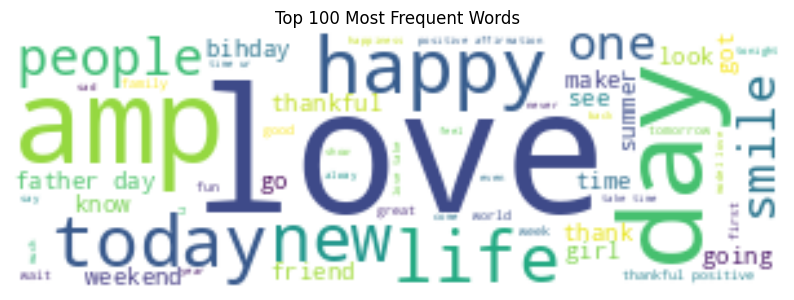

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_words = ' '.join(df['cleaned_tweet'])

wordcloud = WordCloud(
    width=300,
    height=100,
    background_color='white',
    max_words=100
).generate(all_words)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 100 Most Frequent Words')
plt.show()

## **3.1.4 Train Test Split**

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_tweet'],
    df['label'],
    test_size=0.2,
    random_state=42
)

## **3.1.5 Tokenization and Padding**

In [15]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [16]:
X_train_seq

[[2141, 1158, 705, 41, 41],
 [1, 1094, 1, 7590, 246, 1, 30, 2904, 4821, 2905],
 [37, 7591, 37, 102, 1695, 1, 1, 1, 416, 1],
 [240, 180, 321],
 [353, 687, 3600, 7592, 3601, 7593, 5874, 1696],
 [189, 412, 1, 432, 2283, 370, 145, 605, 385, 204, 1, 1095],
 [1997, 378, 1206, 7594, 1333, 622, 76, 1998, 5875, 1],
 [1, 4140, 2673, 1, 3602, 65, 44, 99, 5876, 4822, 1],
 [687, 48, 6, 18, 19, 4, 20, 395, 3, 1],
 [1, 544, 66, 881, 2906, 1],
 [35, 1, 1, 23],
 [121, 5, 63, 9, 862, 297, 339, 1132, 545],
 [10, 723, 1868, 1, 1466, 1054, 1, 1, 10, 1868],
 [1, 457, 256, 822, 443, 55],
 [642, 7595, 272, 318, 643, 44, 11, 504, 278, 318, 47],
 [1, 4823, 56, 9, 22, 2455],
 [304, 657],
 [4, 17, 1096, 7596, 1, 132, 1096, 7596],
 [24, 22, 1, 18, 63, 1537],
 [40, 2907, 1, 5877, 1869, 3603, 1],
 [2142, 1, 149, 4141, 1538, 2456, 3604, 2908, 4142, 512, 7597],
 [486, 644, 1407, 7598, 3605, 1020],
 [413, 33, 2143, 5, 1467, 230, 190, 289, 1],
 [138, 2674, 44, 151, 53, 31, 1207, 882, 7, 4824, 139],
 [1, 4, 422, 4, 40],


In [17]:
max_len = max(len(seq) for seq in X_train_seq)

In [18]:
max_len

20

In [19]:
# max lenght for the validation
max_len_test = max(len(seq) for seq in X_test_seq)
max_len_test

23

In [20]:
import numpy as np
seq_lengths = [len(seq) for seq in X_train_seq]
max_len = int(np.percentile(seq_lengths, 95))

In [21]:
X_train_pad = pad_sequences(X_train_seq, maxlen=25, padding='post', truncating='post')

X_test_pad = pad_sequences(X_test_seq, maxlen=25, padding='post', truncating='post')

In [22]:
X_train_pad.shape

(25569, 25)

# **3.2 Model Building and Trasining**

## **3.2.1 Simple Recurrent Neural Network**

In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# vocab size
vocab_size = 10000
# embedded vector lenght
embedding_dim = 100
# max input sequences
max_length = 25
rnn_units = 64

model = Sequential([

    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim),

    SimpleRNN(units=rnn_units,
              return_sequences=False),

    Dense(1, activation='sigmoid')
])

model.build(input_shape=(None, max_length))

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 25, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,010,625 (3.86 MB)

 Trainable params: 1,010,625 (3.86 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
from tensorflow.keras.metrics import Precision, Recall

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [26]:
from keras.callbacks import EarlyStopping
from sklearn.utils import class_weight

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))
class_weights_dict

{0: np.float64(0.5375478282807047), 1: np.float64(7.158174692049272)}

In [27]:
print("Training Model 1: Simple RNN")
history1 = model.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    class_weight = class_weights_dict,
    callbacks=[early_stopping],
    verbose=1
)

Training Model 1: Simple RNN
Epoch 1/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7903 - loss: 0.4499 - val_accuracy: 0.8682 - val_loss: 0.3235
Epoch 2/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9420 - loss: 0.1645 - val_accuracy: 0.8905 - val_loss: 0.2727
Epoch 3/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9751 - loss: 0.0672 - val_accuracy: 0.8882 - val_loss: 0.2719
Epoch 4/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9814 - loss: 0.0528 - val_accuracy: 0.9183 - val_loss: 0.3378
Epoch 5/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9863 - loss: 0.0388 - val_accuracy: 0.9308 - val_loss: 0.2650
Epoch 6/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9914 - loss: 0.0294 - val_accuracy: 0.9144 - val_loss: 0.2795
Epoch 7/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9892 - loss: 0.0313 - val_accuracy: 0.9206 - val_loss: 0.2533
Epoch 8/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9935 - l

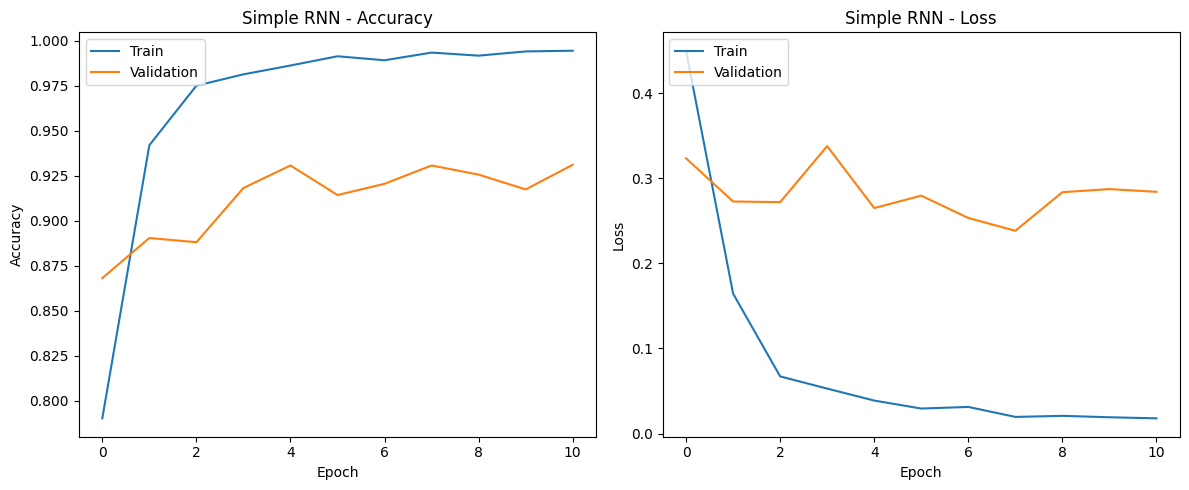

In [28]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.title('Simple RNN - Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.title(f'Simple RNN - Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

Evaluating Model 1: Simple RNN
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

Model 1: Simple RNN Accuracy: 0.9293


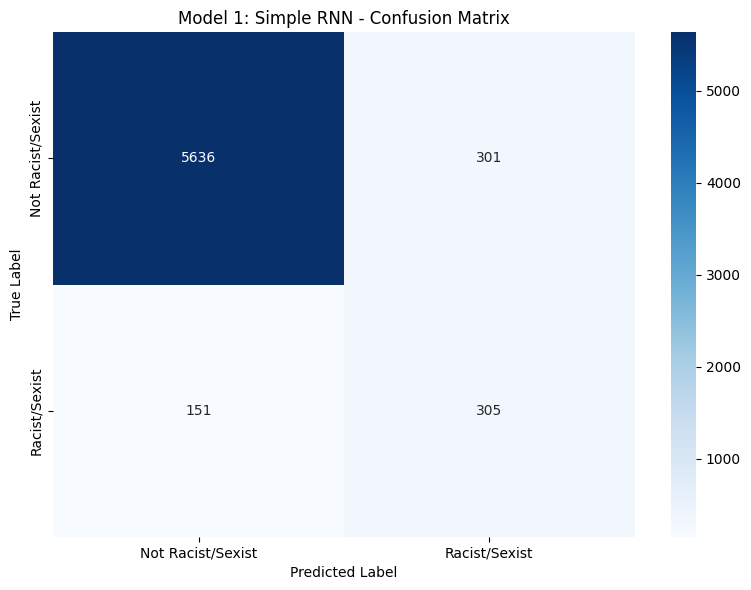


Model 1: Simple RNN Classification Report:
                   precision    recall  f1-score   support

Not Racist/Sexist       0.97      0.95      0.96      5937
    Racist/Sexist       0.50      0.67      0.57       456

         accuracy                           0.93      6393
        macro avg       0.74      0.81      0.77      6393
     weighted avg       0.94      0.93      0.93      6393



In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

def evaluate_model(model, X_test, y_test, model_name):
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n{model_name} Accuracy: {accuracy:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Racist/Sexist', 'Racist/Sexist'],
                yticklabels=['Not Racist/Sexist', 'Racist/Sexist'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    # Classification Report
    print(f"\n{model_name} Classification Report:")
    print(classification_report(y_test, y_pred,
                               target_names=['Not Racist/Sexist', 'Racist/Sexist']))

    return accuracy, y_pred

# Evaluate each model
print("Evaluating Model 1: Simple RNN")
acc1, pred1 = evaluate_model(model, X_test_pad, y_test, "Model 1: Simple RNN")


## **3.2.2 Simple LSTM**

In [30]:
simple_lstm = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim),

    LSTM(units=64,
         dropout=0.2,
         recurrent_dropout=0.2),

    Dense(1, activation='sigmoid')
])

simple_lstm.build(input_shape=(None, max_length))

simple_lstm.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 25, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,042,305 (3.98 MB)

 Trainable params: 1,042,305 (3.98 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
simple_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [32]:
history2 = simple_lstm.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping],
    class_weight = class_weights_dict,
    verbose=1
)

Epoch 1/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 43s 102ms/step - accuracy: 0.7161 - loss: 0.5094 - val_accuracy: 0.8956 - val_loss: 0.2837
Epoch 2/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 35s 95ms/step - accuracy: 0.9130 - loss: 0.2573 - val_accuracy: 0.9171 - val_loss: 0.2519
Epoch 3/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 36s 101ms/step - accuracy: 0.9411 - loss: 0.1686 - val_accuracy: 0.8893 - val_loss: 0.3151


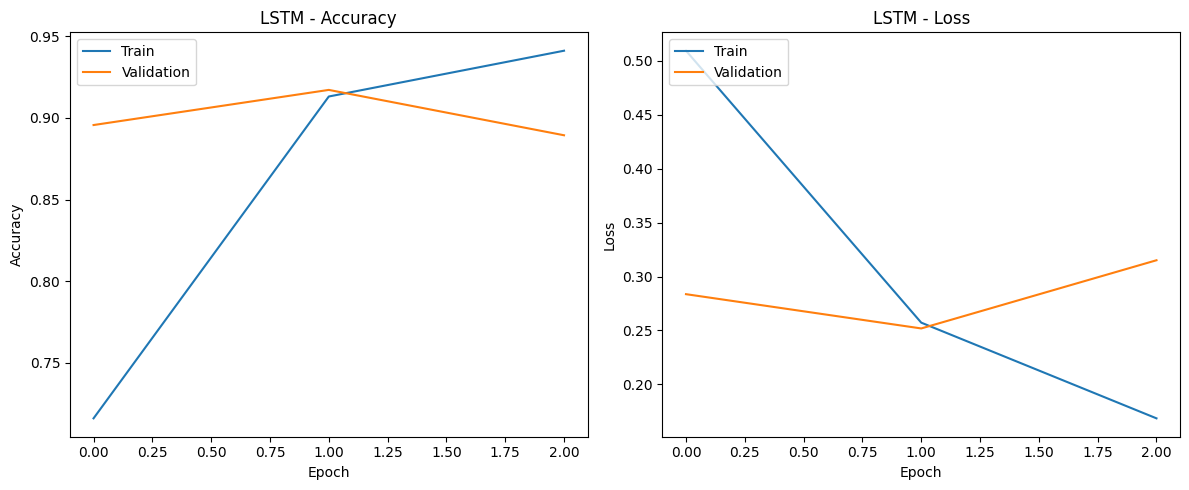

In [33]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.title('LSTM - Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title(f'LSTM - Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()


Evaluating Model 2: LSTM
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step

Model 2: LSTM Accuracy: 0.8997


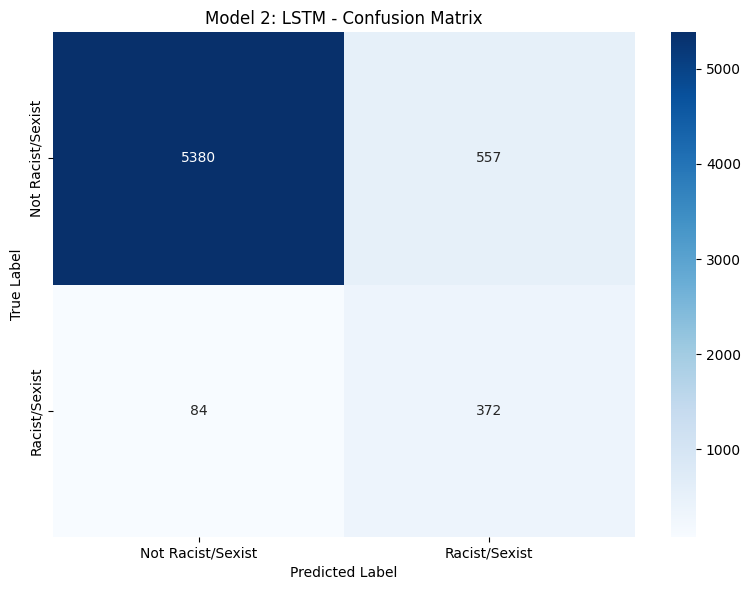


Model 2: LSTM Classification Report:
                   precision    recall  f1-score   support

Not Racist/Sexist       0.98      0.91      0.94      5937
    Racist/Sexist       0.40      0.82      0.54       456

         accuracy                           0.90      6393
        macro avg       0.69      0.86      0.74      6393
     weighted avg       0.94      0.90      0.91      6393



In [34]:
print("\nEvaluating Model 2: LSTM")
acc2, pred2 = evaluate_model(simple_lstm, X_test_pad, y_test, "Model 2: LSTM")

## **3.2.3 LSTM with the Word2Vec**

In [35]:
!pip install gensim

In [36]:
import gensim.downloader as api
embedding_model = api.load('glove-wiki-gigaword-100')

In [37]:
checkpoint_filepath = '/content/drive/MyDrive/AI and ML/ Racist Sexist or Not Dataset/rnn_best.h5'

model_checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_weights_only=False,
    save_best_only=True
)

In [38]:
import pickle

tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# daving the tokensizer
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

vocab_size = 10000
embedding_dim = embedding_model.vector_size
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i >= vocab_size:
        continue
    if word in embedding_model:
        embedding_vector = embedding_model[word]
        embedding_matrix[i] = embedding_vector

model_w2v = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_length,
        trainable=False
    ),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model_w2v.build(input_shape=(None, max_length))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [39]:
embedding_dim

100

In [40]:
model_w2v.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [41]:
model_w2v.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 25, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,042,305 (3.98 MB)

 Trainable params: 42,305 (165.25 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

In [42]:
X_train_pad.shape

(25569, 25)

In [43]:
history_w2v = model_w2v.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping, model_checkpoint_callback],
    class_weight=class_weights_dict,
    verbose=1
)

Epoch 1/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7977 - loss: 0.5122

360/360 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8125 - loss: 0.4468 - val_accuracy: 0.8506 - val_loss: 0.3532
Epoch 2/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8421 - loss: 0.3581

360/360 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.8406 - loss: 0.3563 - val_accuracy: 0.8518 - val_loss: 0.3402
Epoch 3/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.8509 - loss: 0.3256 - val_accuracy: 0.8295 - val_loss: 0.3760


In [44]:
# load the best model or model saved with the best weights

best_model = keras.models.load_model(checkpoint_filepath)

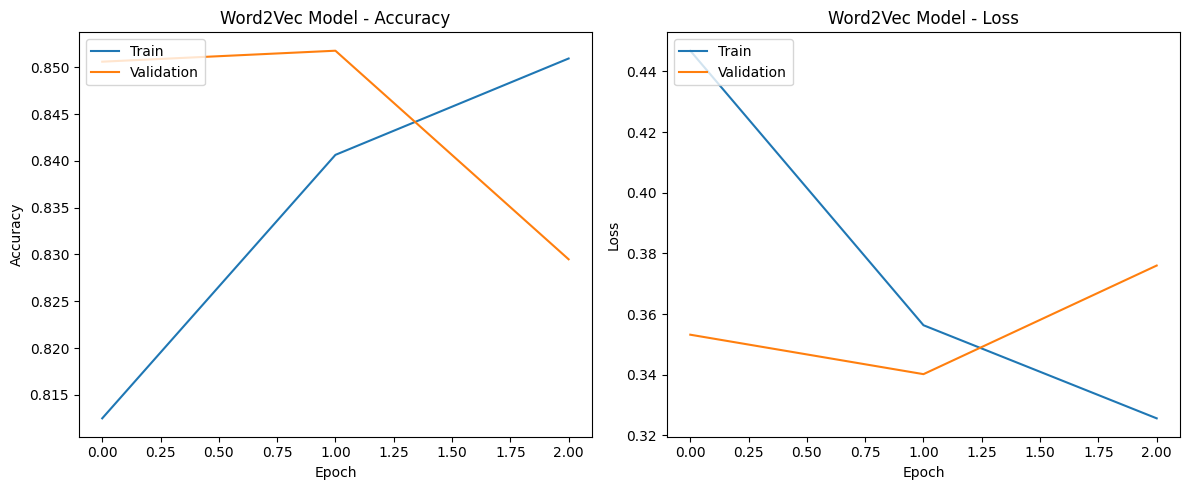

In [45]:
# Visualize the results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_w2v.history['accuracy'])
plt.plot(history_w2v.history['val_accuracy'])
plt.title('Word2Vec Model - Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history_w2v.history['loss'])
plt.plot(history_w2v.history['val_loss'])
plt.title('Word2Vec Model - Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()


Evaluating Model with Word2Vec embeddings:
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Word2Vec Model Accuracy: 0.8462


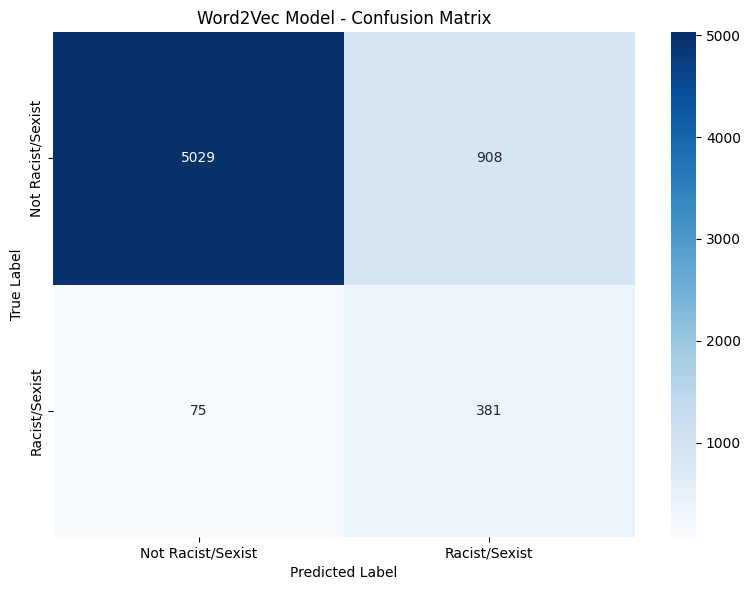


Word2Vec Model Classification Report:
                   precision    recall  f1-score   support

Not Racist/Sexist       0.99      0.85      0.91      5937
    Racist/Sexist       0.30      0.84      0.44       456

         accuracy                           0.85      6393
        macro avg       0.64      0.84      0.67      6393
     weighted avg       0.94      0.85      0.88      6393



(0.8462380728922259,
 array([[0],
        [0],
        [1],
        ...,
        [0],
        [0],
        [1]]))

In [46]:
# Evaluate the Word2Vec model
print("\nEvaluating Model with Word2Vec embeddings:")
evaluate_model(best_model, X_test_pad, y_test, "Word2Vec Model")

In [47]:
!pip install gradio

In [48]:
!pip uninstall -y gradio
!pip install gradio

Found existing installation: gradio 6.14.0
Uninstalling gradio-6.14.0:
  Successfully uninstalled gradio-6.14.0
  Using cached gradio-6.14.0-py3-none-any.whl.metadata (17 kB)
Using cached gradio-6.14.0-py3-none-any.whl (19.7 MB)


In [49]:
import gradio as gr
import pickle
import re
import nltk
import os
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import keras
from tensorflow.keras.preprocessing.text import Tokenizer
import pandas as pd
from google.colab import drive

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/AI and ML/ Racist Sexist or Not Dataset/'
os.makedirs(base_path, exist_ok=True)

train_dataset_path = base_path + 'train_racisit.csv'
test_dataset_path  = base_path + 'test_racisit.csv'
tokenizer_path     = base_path + 'tokenizer.pkl'
model_path         = base_path + 'rnn_best.h5'   # FIXED missing slash

# Load dataset
df = pd.read_csv(train_dataset_path)
X_train = df['tweet']

# Load or create tokenizer
try:
    with open(tokenizer_path, "rb") as f:
        tokenizer = pickle.load(f)
except:
    tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
    tokenizer.fit_on_texts(X_train)
    with open(tokenizer_path, "wb") as f:
        pickle.dump(tokenizer, f)

# Load model
best_model = keras.models.load_model(model_path)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

slang_dict = {
    "gr8": "great","b4": "before","u": "you","ur": "your",
    "r": "are","lol": "laugh","omg": "oh my god",
    "idk": "i do not know","btw": "by the way"
}

def preprocess_text(text):
    contractions = {
        "won't": "will not","can't": "can not","n't": " not",
        "'re": " are","'s": " is","'d": " would",
        "'ll": " will","'t": " not","'ve": " have","'m": " am"
    }

    for k, v in contractions.items():
        text = re.sub(k, v, text)

    text = re.sub(r'\buser\w*\b', '', text, flags=re.IGNORECASE)
    text = text.lower()

    for k, v in slang_dict.items():
        text = re.sub(r'\b' + re.escape(k) + r'\b', v, text)

    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[@#]', '', text)

    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        "]+", flags=re.UNICODE)

    text = emoji_pattern.sub(' ', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]

    return ' '.join(tokens)

def predict_racism_sexism(text):
    text_clean = preprocess_text(text)
    seq = tokenizer.texts_to_sequences([text_clean])
    pad = pad_sequences(seq, padding='post', maxlen=25)
    pred = best_model.predict(pad)[0][0]
    return "Racist/Sexist" if pred >= 0.3 else "Not Racist/Sexist"

interface = gr.Interface(
    fn=predict_racism_sexism,
    inputs=gr.Textbox(lines=2, placeholder="Enter text..."),
    outputs="text",
    title="Racism/Sexism Detection"
)

interface.launch(share=True)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://237950bb4154c879c7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
